# Customer Segmentation Using RFM Analysis and K-Means Clustering

## Introduction
**RFM Analysis** (Recency, Frequency, Monetary) analysis is a technique used to segment customers based on how **recently** they made a purchase, how **often** they make purchases, and **how much money** they spend per purchase.  

RFM analysis helps identify loyal customers, high spenders, inactive users, and more. This is important for enabling targeted marketing and campaigns.

### Goal:
The goal of this analysis is to segment customers based on their purchasing behavior to help businesses personalize marketing efforts and improve customer retention.

### Data set Description
**Name:** Online Retail Data set  
**Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/352/online+retail)  

This data set contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.The company mainly sells unique all-occasion gifts. Many customers of the company are wholesalers.


| Variable Name | Role    | Type        | Description                                                                 | Units    |
|---------------|---------|-------------|-----------------------------------------------------------------------------|----------|
| InvoiceNo     | ID      | Categorical | a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation |          |
| StockCode     | ID      | Categorical | a 5-digit integral number uniquely assigned to each distinct product        |    -      |
| Description   | Feature | Categorical | product name                                                                |    -      |
| Quantity      | Feature | Integer     | the quantities of each product (item) per transaction                       |    -      |
| InvoiceDate   | Feature | Date        | the day and time when each transaction was generated                        |    -      |
| UnitPrice     | Feature | Continuous  | product price per unit                                                      | sterling  |
| CustomerID    | Feature | Categorical | a 5-digit integral number uniquely assigned to each customer                |     -     |
| Country       | Feature | Categorical | the name of the country where each customer resides                         |      -    | 

### Tools
- Python
  - Data Manipulation: *`Pandas`*, *`NumPy`*
  - Data Visualization: *`Matplotlib`*, *`Seaborn`*
  - Machine Learning/Clustering: *`Scikit-learn`*

In [1]:
# Import packages for data manipulation and analysis
import pandas as pd
import numpy as np

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore FutureWarnings
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

## Load and Explore the dataset

In [2]:
# Load the dataset
df = pd.read_csv("data/rfm_customer_segments.csv")

# Dataset preview
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/01/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/01/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/01/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/01/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/01/2010 08:26,3.39,17850.0,United Kingdom


In [3]:
# Check the dataset info including the data types and missing values
df.info()

# Check for NaN (null values) in each column
print(f"\nNull Values per Column: \n{df.isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

Null Values per Column: 
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


### Summary statistics

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


From the summary statistics we notice that there are negative values `Quantity` and `UnitPrice` which is not plausible and needs to be addressed.

## Data Cleaning & Preparation

In this step we will:
- Remove rows with missing Customer IDs
- Drop canceled transactions (`InvoiceNo` starting with 'c')
- Filter out negative or zero quantities and prices
- Convert data types (`CustomerID` to string)
- Create a `TotalPrice` column for later use

In [5]:
# Drop rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Convert CustomerID to string
df['CustomerID'] = df['CustomerID'].astype(str)

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove canceled orders
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative or zero quantity and unit price
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']


## RFM Feature Engineering

To segment customers based on behavior, we compute three RFM metrics for each customer:
- **Recency:** Number of days since the last purchase
- **Frequency:** Total number of unique purchases
- **Monetary:** Total amount spent

These metrics help identify loyal customers, high spenders, and those at risk of churning.

In [6]:
# Set the reference date (1 day after the last purchase)
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date for Recency calculation: {reference_date.date()}\n\n")

# Aggregate RFM metrics
# Group by customer
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                     # Frequency
    'TotalPrice': 'sum'                                         # Monetary
})

# Rename columns
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

# Display first few rows
rfm.head()

Reference date for Recency calculation: 2011-12-10




,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


## RFM Scoring

We'll now apply scores (1 - 5) to the RFM values:
- **Recency:** Lower is better -> lower recency value = higher score
- **Frequency & Monetary:** Higher is better -> more purchases/spending = higher score

We’ll then combine these into a single RFM Score to simplify segmentation.

In [7]:
# RFM Scoring using quintiles (1 = low, 5 = high)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

# Combine the scores into a single RFM Score (as a string)
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Display sample
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1797.24,2,4,4,244
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112


## Customer Segmentation

Based on the combined RFM Score, we'll assign customers into predefined segments such as:
- Champions
- Loyal Customers
- Big Spenders
- At Risk
- Lost
- Others

These segments help businesses target marketing strategies effectively.

In [8]:
# Function to assign segments based on RFM_Score
def segment_customer(rfm):
    score = rfm['RFM_Score']
    
    if score == '555':
        return 'Champion'
    elif rfm['R_Score'] >= 4 and rfm['F_Score'] >= 4:
        return 'Loyal Customer'
    elif rfm['R_Score'] >= 4 and rfm['M_Score'] >= 4:
        return 'Big Spender'
    elif rfm['R_Score'] <= 2 and rfm['F_Score'] <= 2:
        return 'At Risk'
    elif rfm['R_Score'] == 1:
        return 'Lost'
    else:
        return 'Others'

# Apply segmentation
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Show sample
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,At Risk
12347.0,2,7,4310.00,5,5,5,555,Champion
12348.0,75,4,1797.24,2,4,4,244,Others
12349.0,19,1,1757.55,4,1,4,414,Big Spender
12350.0,310,1,334.40,1,1,2,112,At Risk


## Visualizing Customer Segments

To better understand the distribution and value of different customer groups, we’ll visualize:
- The number of customers in each segment
- The distribution of Recency, Frequency, and Monetary values per segment

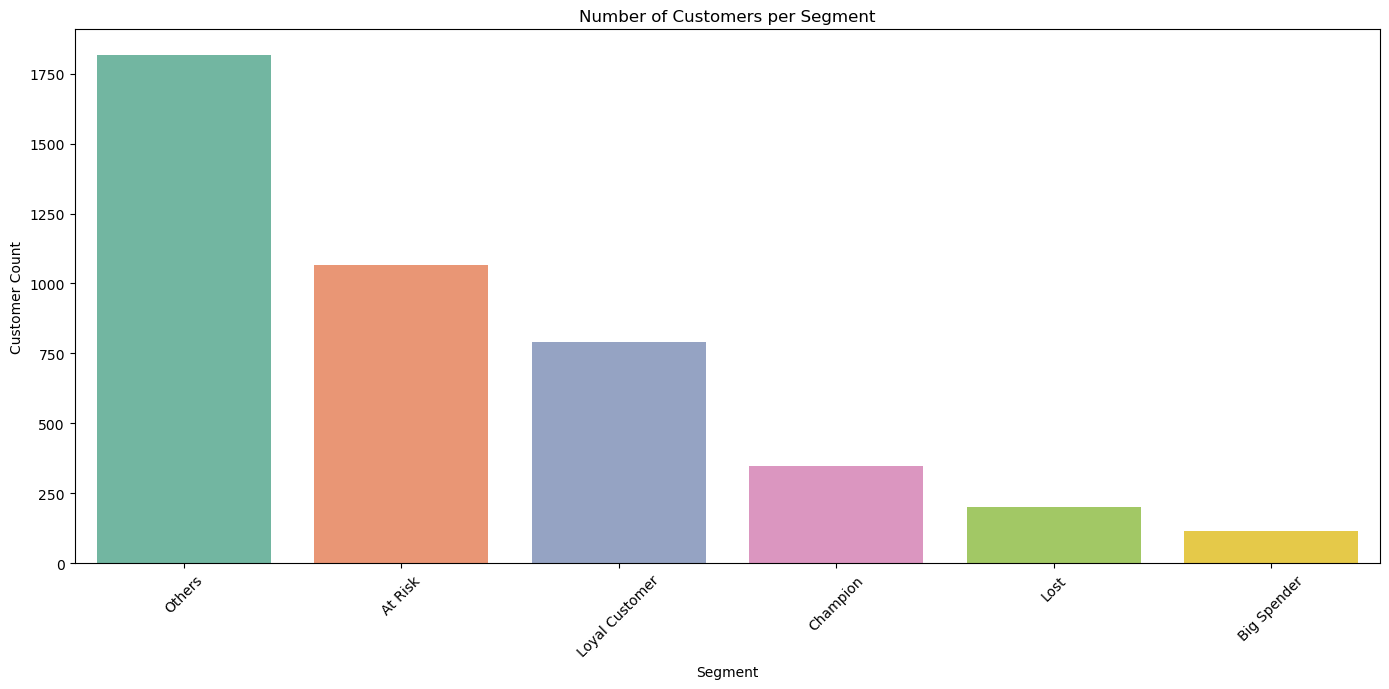

In [9]:
# Chart for visualizing the number of customers per segment
plt.figure(figsize=(14, 7))
sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='Set2')
plt.title('Number of Customers per Segment')
plt.xticks(rotation=45)
plt.xlabel('Segment')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.savefig("images/customer_segments_chart.png",
           dpi=300) # Save the chart
plt.show()

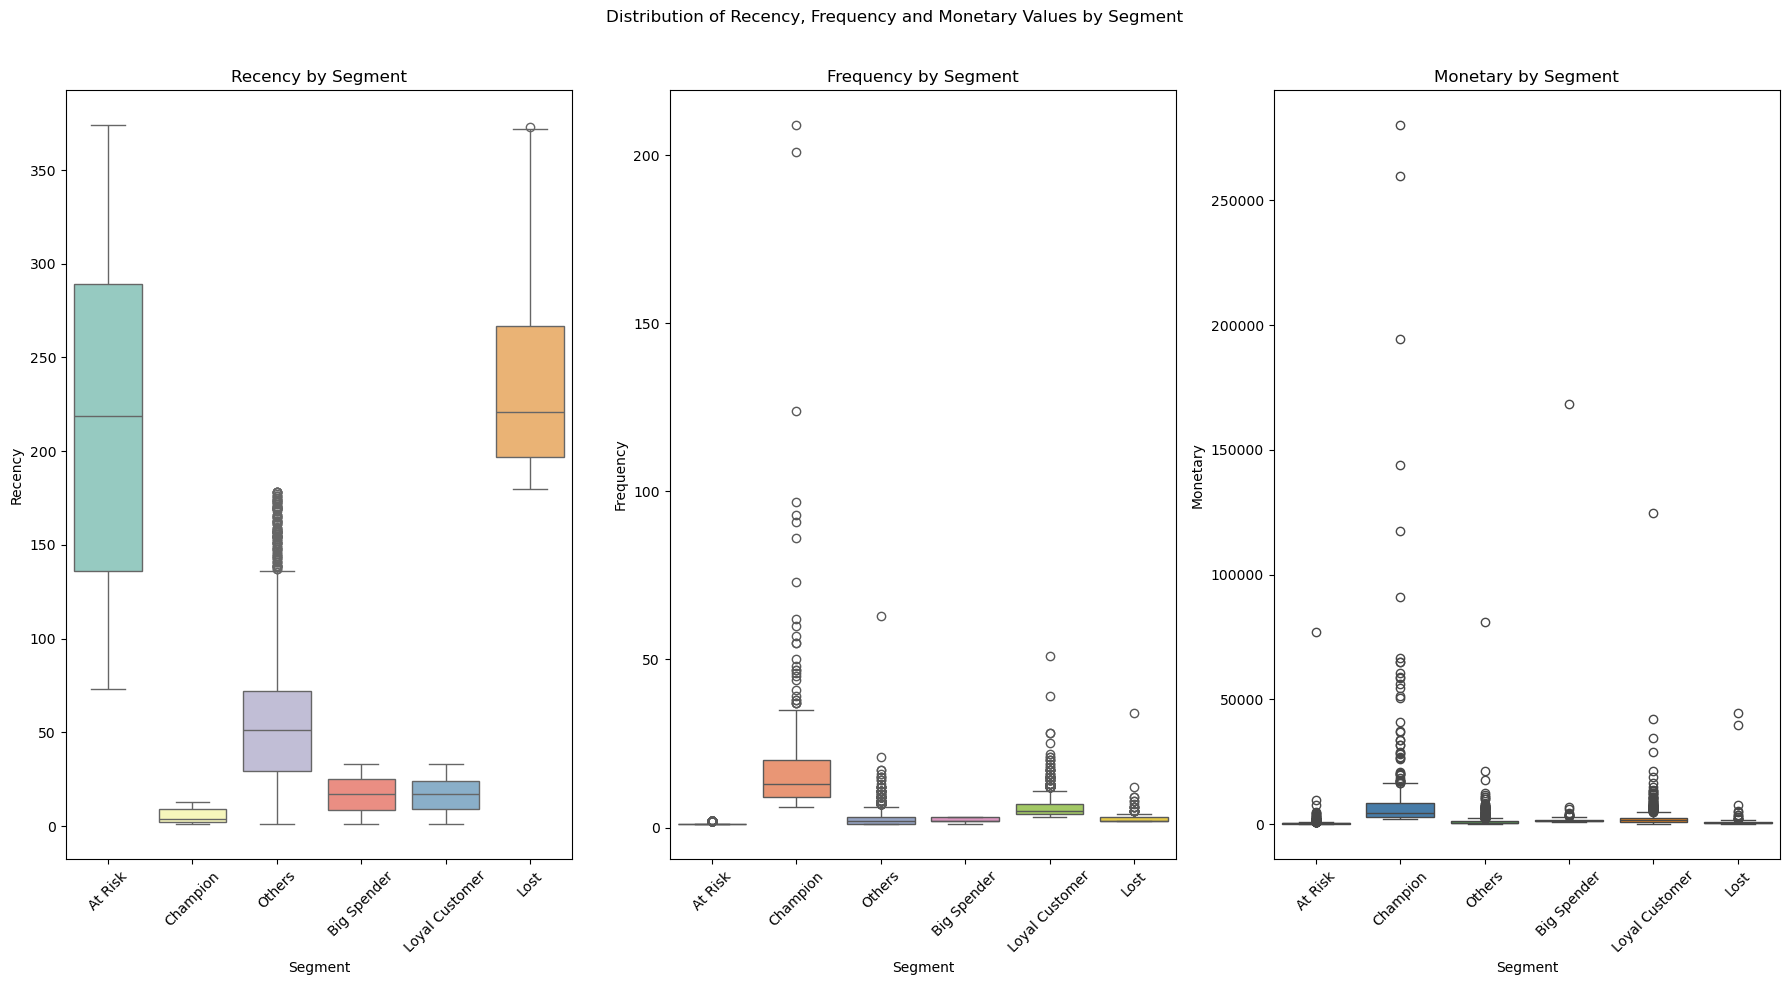

In [10]:
# Plotting rfm distribution by segment
fig, axes = plt.subplots(1, 3, figsize=(18, 10))
plt.suptitle("Distribution of Recency, Frequency and Monetary Values by Segment\n\n")

sns.boxplot(data=rfm, x='Segment', y='Recency', ax=axes[0], 
            palette='Set3')
axes[0].set_title('Recency by Segment')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=rfm, x='Segment', y='Frequency', ax=axes[1],
            palette='Set2')
axes[1].set_title('Frequency by Segment')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(data=rfm, x='Segment', y='Monetary', ax=axes[2],
            palette='Set1')
axes[2].set_title('Monetary by Segment')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("images/rfm_distribution_by_segment.png",
           dpi=300)
plt.show()